# **Task G**

- Name: Vaishnavi Agarwal
- Roll No.: 230150028

# Importing Libraries

In [6]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import os


# **(b) Loading Dataset**

In [7]:
data_path = "My_Voice/"
phonemes = ['a.wav', 'e.wav', 'o.wav', 'sh.wav']

audio_signals = {}
fs = 16000  # in Hz

# load WAV files and scale amplitudes to [-1, 1]
for ph in phonemes:
    rate, data = wavfile.read(os.path.join(data_path, ph))
    if rate != fs:
        print(f"Warning: {ph} has sampling rate {rate}, expected {fs}")
    if data.ndim > 1:
        data = data.mean(axis=1)  # average both channels
    
    data = data.astype(np.float32)
    data = data / np.max(np.abs(data))  # scale between ±1
    audio_signals[ph] = data


Plot time-domain waveforms

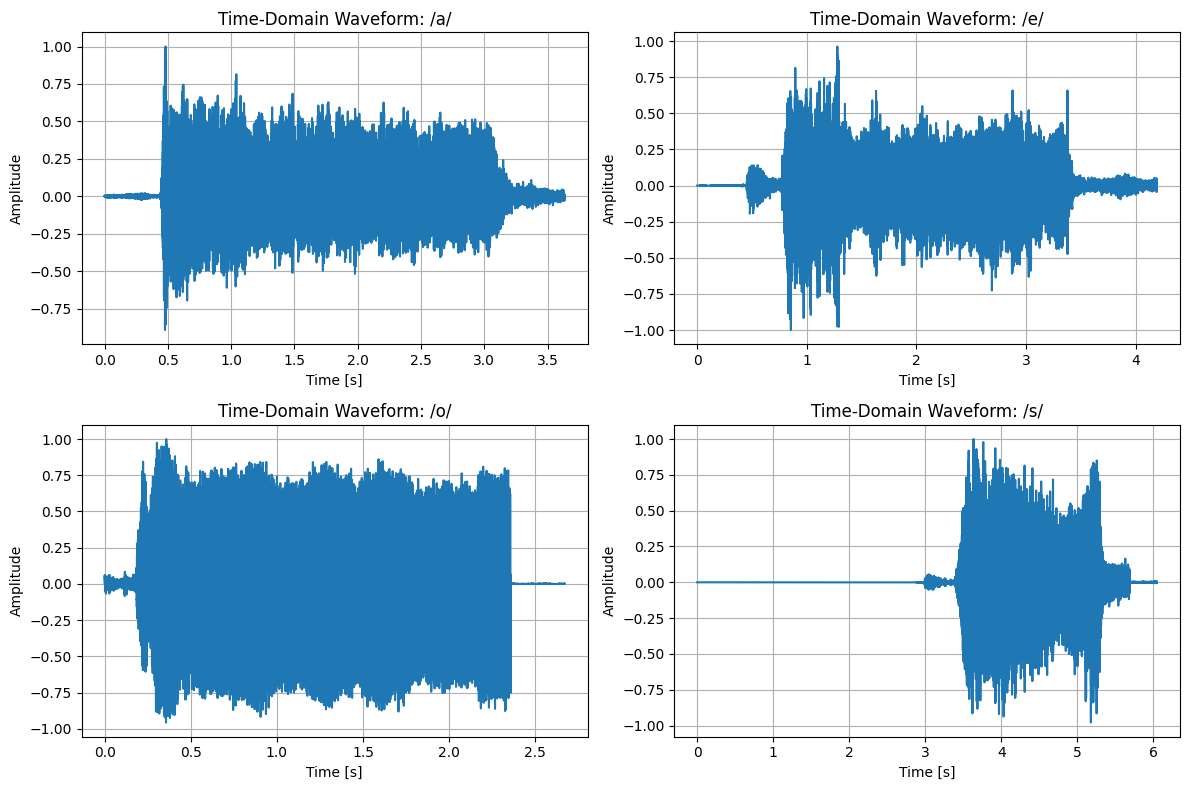

In [8]:
plt.figure(figsize=(12, 8))

for i, ph in enumerate(phonemes):
    plt.subplot(2, 2, i+1)
    t = np.arange(len(audio_signals[ph])) / fs  # time axis in seconds
    plt.plot(t, audio_signals[ph])
    plt.title(f"Time-Domain Waveform: /{ph[0]}/")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.show()


# **Step (c) DFT spectrum (log-magnitude)**

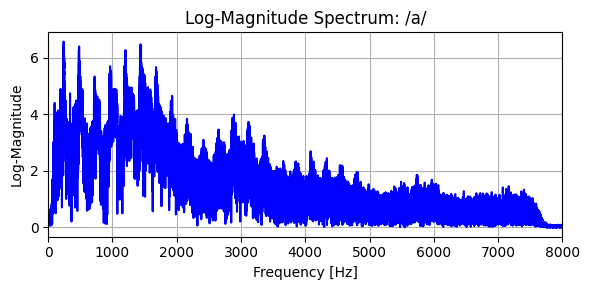

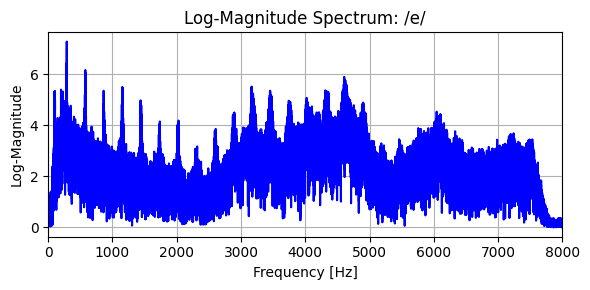

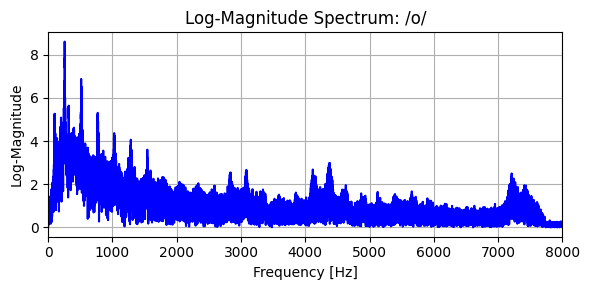

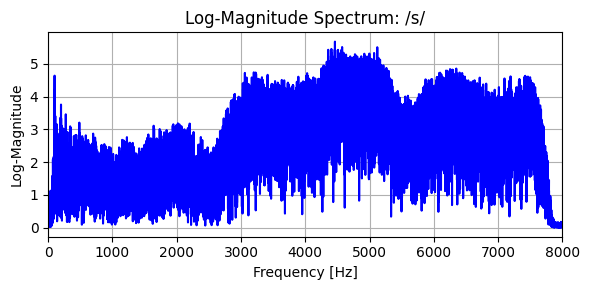

In [11]:
# DFT plots for each phoneme
for ph in phonemes:
    X = np.fft.rfft(audio_signals[ph])
    X_mag = np.abs(X)
    freqs = np.fft.rfftfreq(len(audio_signals[ph]), d=1/fs)
    
    plt.figure(figsize=(6,3))
    plt.plot(freqs, np.log1p(X_mag), color='b')
    plt.xlim([0, 8000])
    plt.title(f"Log-Magnitude Spectrum: /{ph[0]}/")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Log-Magnitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# **Observations**

Vowels (/a/, /e/, /o/) show clear harmonic peaks (periodic), mainly below 6 kHz.

Fricative /sh/ is noisy, spread across a wider frequency range, less periodic.

Each vowel has distinct formant frequencies (peaks at certain frequencies) which makes them recognizable.

Amplitude scaling helps in comparing spectral shapes visually without bias due to loudness.